# Lab 4
### Contrast Enhancement

http://scikit-image.org/docs/dev/api/skimage.exposure.html#skimage.exposure.equalize_hist



In [1]:
from commonfunctions import *
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
import skimage.io as io
import matplotlib.pyplot as plt
import numpy as np
from skimage import img_as_float


# Show the figures / plots inside the notebook
%matplotlib inline
from skimage.color import rgb2gray


def show_images(images,titles=None):
    #This function is used to show image(s) with titles by sending an array of images and an array of associated titles.
    # images[0] will be drawn with the title titles[0] if exists
    # You aren't required to understand this function, use it as-is.
    n_ims = len(images)
    if titles is None: titles = ['(%d)' % i for i in range(1,n_ims + 1)]
    fig = plt.figure()
    n = 1
    for image,title in zip(images,titles):
        a = fig.add_subplot(1,n_ims,n)
        if image.ndim == 2: 
            plt.gray()
        plt.imshow(image)
        a.set_title(title)
        n += 1
    fig.set_size_inches(np.array(fig.get_size_inches()) * n_ims)
    plt.show()

<>:18: SyntaxWarning: invalid escape sequence '\P'
<>:18: SyntaxWarning: invalid escape sequence '\P'
C:\Users\gehad\AppData\Local\Temp\ipykernel_7132\2976013818.py:18: SyntaxWarning: invalid escape sequence '\P'
  image = io.imread('imgs\Picture1.png')


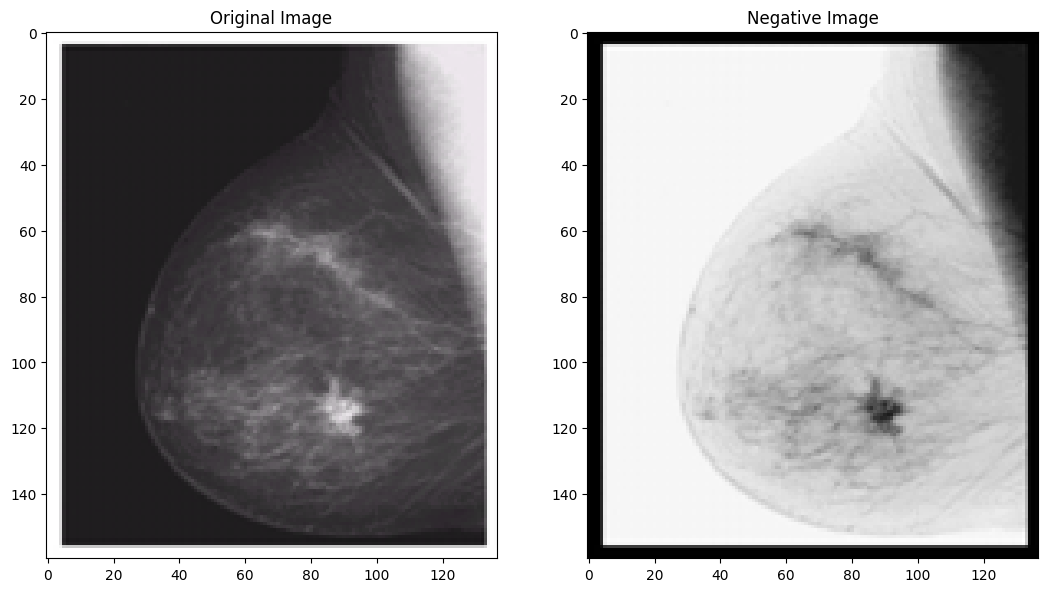

In [3]:
'''
1
Negative Transformation
'''
def negative_transformation(image):
   
    if image.ndim > 2 and image.shape[-1] == 4:
      
        image_rgb = image[..., :3]
    else:
        image_rgb = image
    image_gray = rgb2gray(image_rgb) 
    image_uint8 = (image_gray * 255).astype(np.uint8)
    negative_image = 255 - image_uint8
    return negative_image


image = io.imread('imgs\Picture1.png')
negative_image = negative_transformation(image)
show_images([image, negative_image], ['Original Image', 'Negative Image'])




<>:17: SyntaxWarning: invalid escape sequence '\P'
<>:17: SyntaxWarning: invalid escape sequence '\P'
C:\Users\gehad\AppData\Local\Temp\ipykernel_7132\48300179.py:17: SyntaxWarning: invalid escape sequence '\P'
  image = io.imread('imgs\Picture2.png')


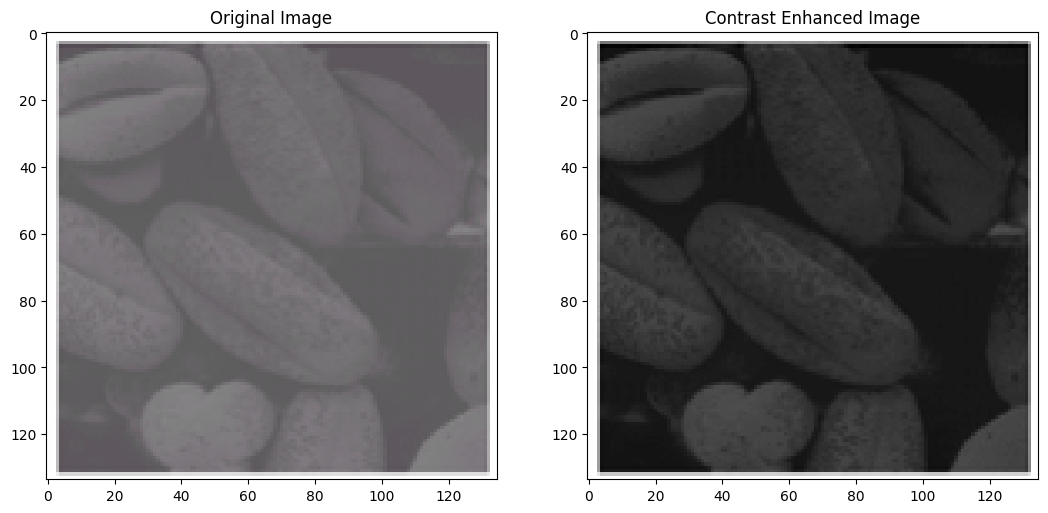

In [4]:
'''
2
Contrast Enhancement
'''
def Contrast_enhancement(image):
    if image.ndim == 3:
        image = np.mean(image, axis=2).astype(np.uint8)
    
    result = image.copy().astype(float)
    
    mask = (image >= 0) & (image <= 100)
    result[mask] = 50 + ((image[mask] - 0) * (200 - 50) / (100 - 0))
    
    
    result = np.clip(result, 0, 255).astype(np.uint8)
    return result
image = io.imread('imgs\Picture2.png')


enhanced = Contrast_enhancement(image)
show_images([image, enhanced], ['Original Image', 'Contrast Enhanced Image'])




<>:14: SyntaxWarning: invalid escape sequence '\P'
<>:14: SyntaxWarning: invalid escape sequence '\P'
C:\Users\gehad\AppData\Local\Temp\ipykernel_7132\2172847967.py:14: SyntaxWarning: invalid escape sequence '\P'
  image = io.imread('imgs\Picture2.png')


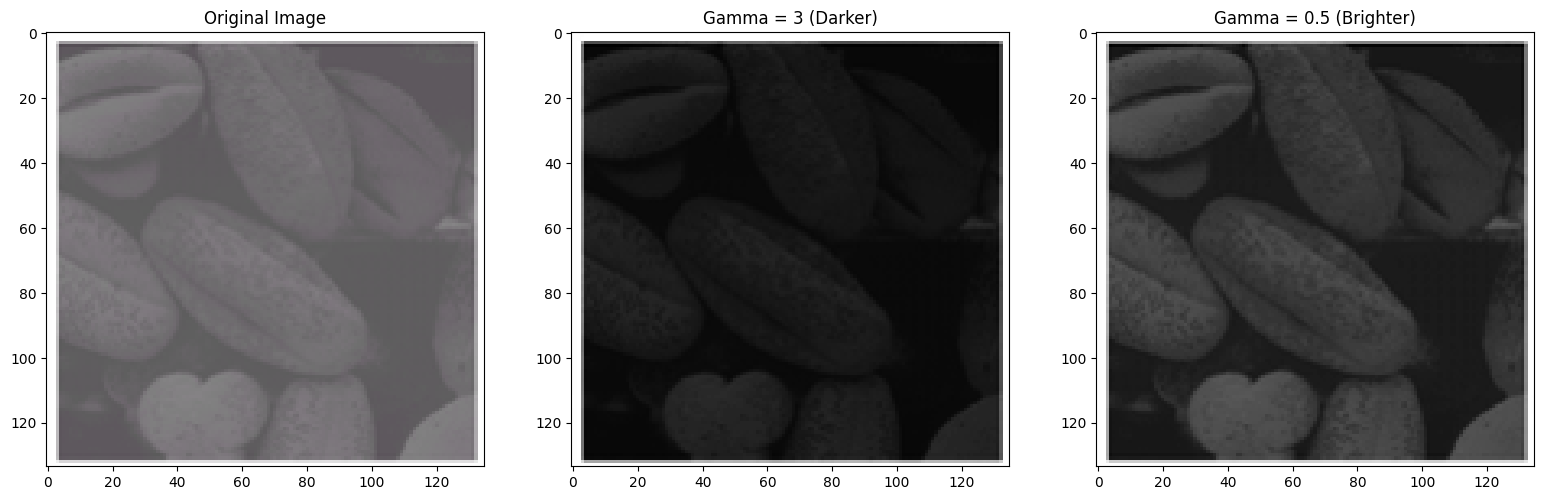

In [5]:
'''
3
Gamma Correction
'''
def Gamma_Correction(image, c, gamma):

    if image.ndim == 3:
        image = np.mean(image, axis=2)

    image = image / 255.0
    corrected = c * np.power(image, gamma)
    corrected = np.clip(corrected, 0, 1)
    return corrected
image = io.imread('imgs\Picture2.png')
gamma3 = Gamma_Correction(image, c=1, gamma=3)
gamma05 = Gamma_Correction(image, c=1, gamma=0.5)
show_images(
    [image, gamma3, gamma05],
    ['Original Image', 'Gamma = 3 (Darker)', 'Gamma = 0.5 (Brighter)']
)



<>:50: SyntaxWarning: invalid escape sequence '\p'
<>:50: SyntaxWarning: invalid escape sequence '\p'
C:\Users\gehad\AppData\Local\Temp\ipykernel_7132\2035925833.py:50: SyntaxWarning: invalid escape sequence '\p'
  eq_pout = getImageWithHist("imgs\pout", "tif")


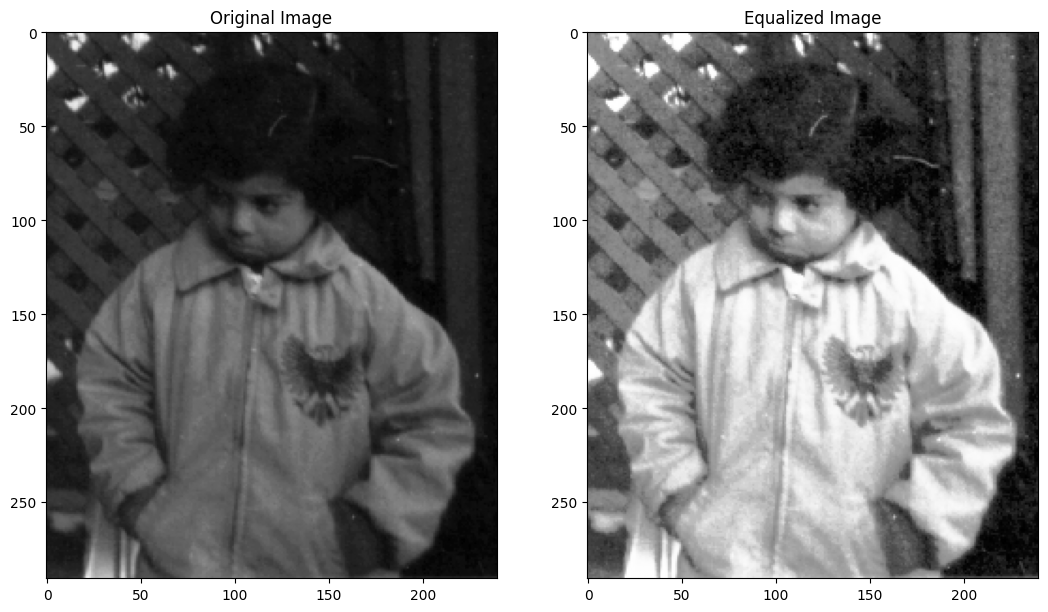

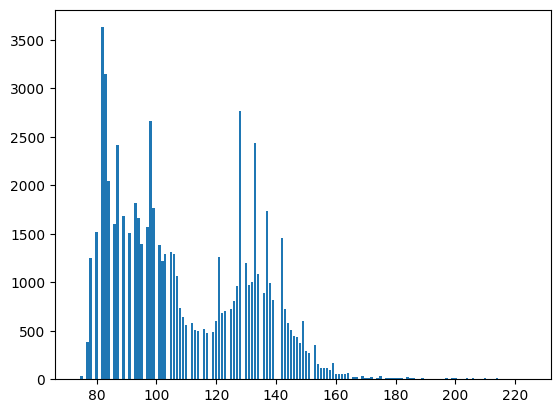

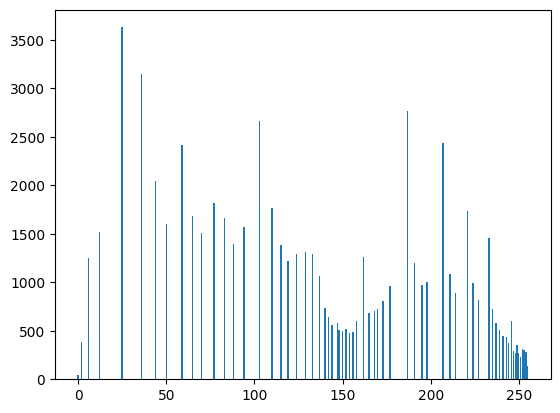

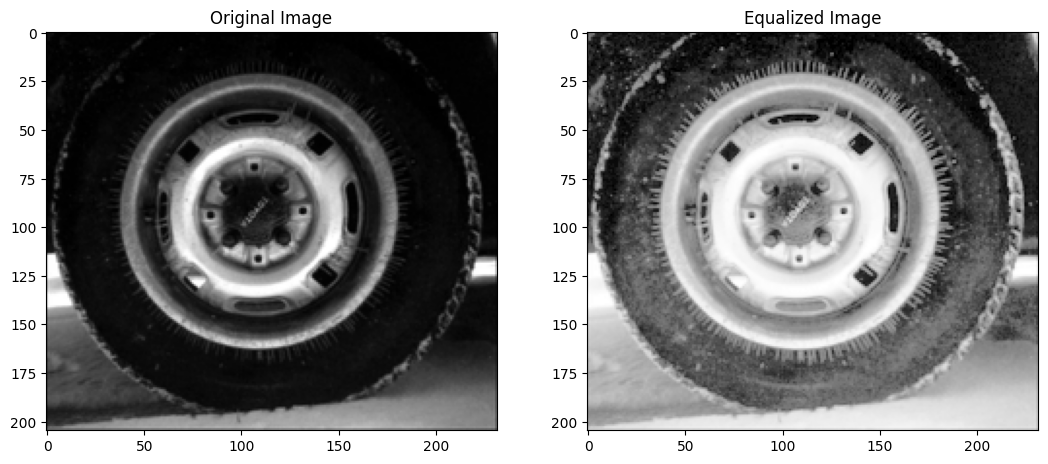

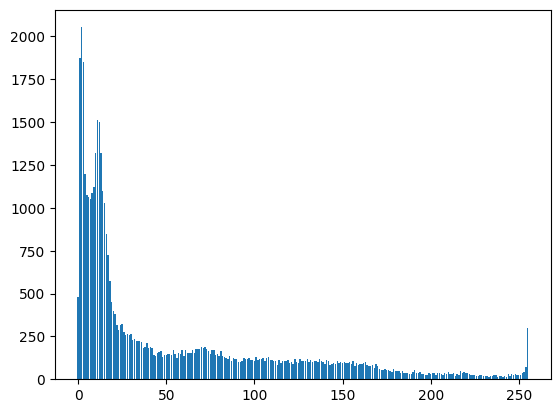

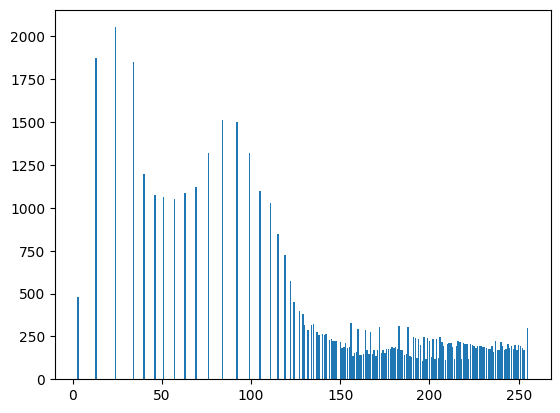

In [6]:
'''
4 Histogram Eq.
Note: Histogram function of skimage returns only present intensity values not all 255
You can use showHist function from commonfunctions file
'''

def getImageWithHist(name, ext, nbins=256):
    
    img = io.imread(f"{name}.{ext}")
    
    if img.ndim == 3:
        img = rgb2gray(img)
        img = (img * 255).astype(np.uint8)  
    else:
        img = img.astype(np.uint8)
    
    N, M = img.shape
    G = 256 

    H = np.zeros(G)
    for p in range(N):
        for q in range(M):
            H[img[p, q]] += 1

   
    H_c = np.zeros(G)
    H_c[0] = H[0]
    for p in range(1, G):
        H_c[p] = H_c[p-1] + H[p]

   
    T = np.round((G - 1) * H_c / (N * M))

    
    equalized_img = np.zeros_like(img)
    for p in range(N):
        for q in range(M):
            equalized_img[p, q] = T[img[p, q]]

    equalized_img = equalized_img.astype(np.uint8)

  
    show_images([img, equalized_img], ["Original Image", "Equalized Image"])
   
    showHist(img)
 
    showHist(equalized_img)

    return equalized_img
eq_pout = getImageWithHist("imgs\pout", "tif")
eq_tire = getImageWithHist("imgs/tire", "tif")




extra task

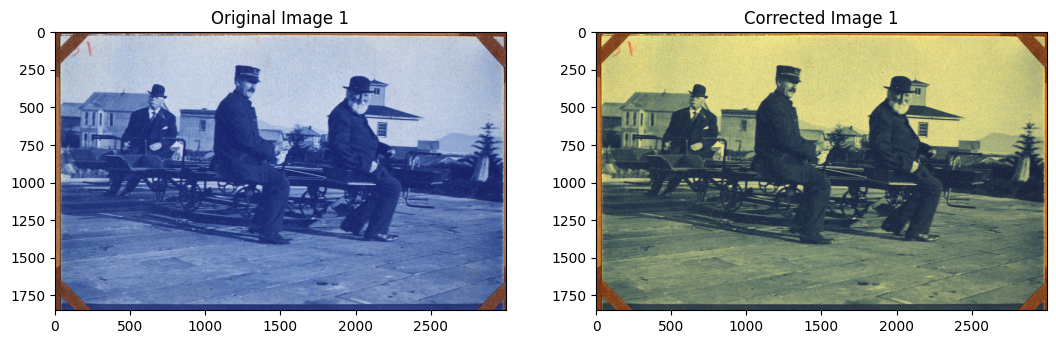

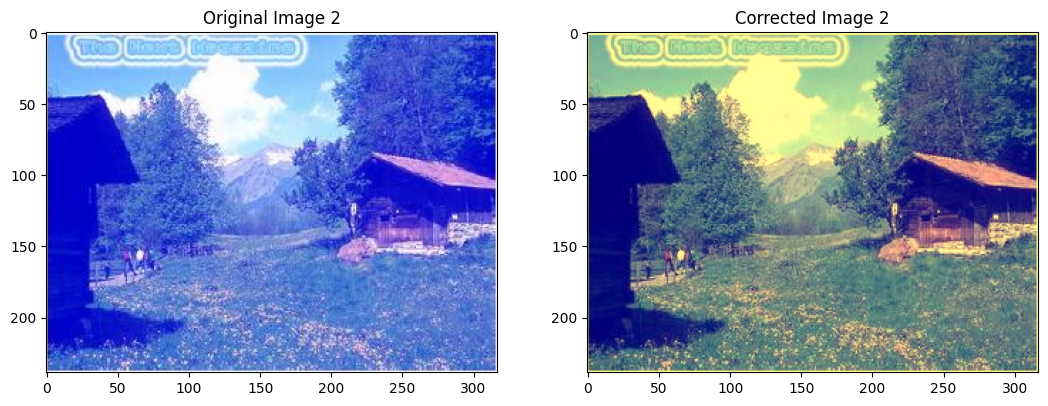

In [13]:




def remove_blue_tint(image):
   
    img = image.astype(np.float32) / 255.0

  
    R = img[:, :, 0]
    G = img[:, :, 1]
    B = img[:, :, 2]

  
    R = np.clip(R * 1.15, 0, 1)
    G = np.clip(G * 1.05, 0, 1)
    B = np.clip(B * 0.60, 0, 1)

    
    corrected = np.stack((R, G, B), axis=2)
    
    
    corrected = (corrected * 255).astype(np.uint8)
    return corrected


img1 = io.imread('imgs\\Lab 4 extra task images\\1.jpg')
img2 = io.imread('imgs\\Lab 4 extra task images\\2.jpg')



corrected1 = remove_blue_tint(img1)
corrected2 = remove_blue_tint(img2)

show_images([img1, corrected1], ['Original Image 1', 'Corrected Image 1'])
show_images([img2, corrected2], ['Original Image 2', 'Corrected Image 2'])
